# 04 / 예측 모델링 - AI4I 2020

**목표**
1. Phase 2에서 만든 물리 기반 피처가 실제로 고장 예측을 개선하는가? (Raw 센서만 vs 물리 기반 피처 추가 성능 비교)
2. Phase 3에서의 인사이트를 학습/검증 데이터셋을 사용한 모델 결과에서 다시 확인할 수 있는가?

**모델 3종 (성격이 다른 관점)**
- 로지스틱 회귀: 해석형. 오즈비로 "각 물리량이 고장 확률을 어떻게 바꾸나".
- RandomForest: 비선형/상호작용. 공선성에 강함.
- Hotelling T제곱: 정상만 학습하는 비지도 이상탐지. 고장 데이터가 희귀한 상황에서 유리. 어느 변수가 알람을 발생했는지 확인.

평가지표: 불균형이 심하므로 정확도 대신 PR-AUC를 주력으로, recall/F1을 함께 확인.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import LedoitWolf
from sklearn.metrics import (roc_curve, roc_auc_score, average_precision_score,
                             recall_score, f1_score, precision_score, confusion_matrix)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

_here = Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / 'src').is_dir()), _here)
sys.path.insert(0, str(ROOT))
from src.config import FEATURES_CSV, FIGDIR
from src.physics import COL_OMEGA, COL_POWER, COL_DT, COL_STRAIN

FIGDIR.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(FEATURES_CSV, encoding='utf-8-sig')
feat['Type_ord'] = feat['Type'].map({'L': 0, 'M': 1, 'H': 2})
target = 'Machine failure'
print('shape:', feat.shape)
print('고장 비율:', round(feat[target].mean(), 4))

shape: (10000, 19)
고장 비율: 0.0339


## 1. 피처셋 정의

Phase 1에서 걸러낸 누수 컬럼을 다시 제외한다. 식별자(UDI, Product ID)와
타겟 구성요소(TWF/HDF/PWF/OSF/RNF)는 정답을 미리 알려주므로 입력에서 제외.

두 피처셋을 비교한다.
- RAW: 원시 센서 5종 + 등급. 물리 기반 피처 없이 센서값 그대로.
- PHYS: RAW + 물리 기반 파생 피처 3종(동력 P, 온도차 dT, 누적응력).

각속도 omega는 제외한다. omega = 2*pi*N/60 회전속도 N의 상수배 -> 중복이라 제외.

In [2]:
RAW = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
       'Torque [Nm]', 'Tool wear [min]', 'Type_ord']
PHYS = RAW + [COL_POWER, COL_DT, COL_STRAIN]

print('RAW  피처:', RAW)
print('PHYS 피처:', PHYS)
print('\nPHYS = RAW + 물리 3종. omega(각속도)는 N의 상수배라 제외.')

RAW  피처: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_ord']
PHYS 피처: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_ord', 'Mechanical power [W]', 'Temp difference [K]', 'Overstrain [min*Nm]']

PHYS = RAW + 물리 3종. omega(각속도)는 N의 상수배라 제외.


## 2. 학습/검증 데이터 분리

고장이 3.39%라 무작위 분할은 검증셋 고장 수를 들쭉날쭉하게 만든다.
stratify로 두 셋의 고장 비율을 동일하게 맞춘다. Phase 3는 전체 데이터로 인사이트를
발견했는데, 여기서는 학습에서 정한 것을 처음 보는 검증셋에서 평가한다.

In [3]:
y = feat[target].values
idx_tr, idx_te = train_test_split(np.arange(len(feat)), test_size=0.3,
                                  stratify=y, random_state=0)
y_tr, y_te = y[idx_tr], y[idx_te]
print(f'학습 {len(idx_tr)}건 (고장 {y_tr.sum()}, {y_tr.mean()*100:.2f}%)')
print(f'검증 {len(idx_te)}건 (고장 {y_te.sum()}, {y_te.mean()*100:.2f}%)')

def get_X(cols, rows):
    return feat.loc[rows, cols].values

학습 7000건 (고장 237, 3.39%)
검증 3000건 (고장 102, 3.40%)


## 3. 다중공선성 점검 (VIF)

VIF(분산팽창인자)는 한 피처를 나머지 피처로 회귀했을 때의 1/(1-R^2)이다. 10을 넘으면 다중공선성이 있는 것으로 본다.
dT = 공정온도 - 공기온도 라 두 온도의 정확한 선형결합 -> VIF 무한대가 나와야 정상.

In [4]:
def vif_series(Xdf):
    out = {}
    for c in Xdf.columns:
        others = [o for o in Xdf.columns if o != c]
        r2 = LinearRegression().fit(Xdf[others], Xdf[c]).score(Xdf[others], Xdf[c])
        out[c] = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
    return pd.Series(out).sort_values(ascending=False)

num_phys = [c for c in PHYS if c != 'Type_ord']
vif = vif_series(feat.loc[idx_tr, num_phys])
print('PHYS 수치 피처 VIF (학습셋):')
print(vif.round(2).to_string())
print('\ndT가 무한대 = 두 온도의 완전 선형결합. 동력 P도 높음(토크x각속도).')
print('-> 트리 계열은 상관 x. 로지스틱은 (1)정규화 (2)오즈비해석은 다중공선성 변수를 제외한 데이터셋으로 확인.')

PHYS 수치 피처 VIF (학습셋):
Air temperature [K]          inf
Process temperature [K]      inf
Temp difference [K]          inf
Torque [Nm]                51.21
Mechanical power [W]       32.07
Overstrain [min*Nm]        19.96
Tool wear [min]            17.28
Rotational speed [rpm]      5.82

dT가 무한대 = 두 온도의 완전 선형결합. 동력 P도 높음(토크x각속도).
-> 트리 계열은 상관 x. 로지스틱은 (1)정규화 (2)오즈비해석은 다중공선성 변수를 제외한 데이터셋으로 확인.


## 4. 로지스틱 회귀

표준화 + L2 정규화 로지스틱. class_weight=balanced 로 불균형 보정.
L2 정규화는 공선성 하에서도 예측을 안정시키므로 RAW vs PHYS 성능 비교가 안정적.

평가는 임계값에 무관한 PR-AUC/ROC-AUC를 메인으로 확인. recall/F1은 학습셋에서
Youden으로 고른 임계를 검증셋에 적용해 계산.

In [5]:
def pick_threshold(y_true, score):
    fpr, tpr, thr = roc_curve(y_true, score)
    return thr[int(np.argmax(tpr - fpr))]

results = []
def evaluate(name, s_tr, s_te):
    cut = pick_threshold(y_tr, s_tr)
    yhat = (s_te >= cut).astype(int)
    row = dict(model=name,
               PR_AUC=average_precision_score(y_te, s_te),
               ROC_AUC=roc_auc_score(y_te, s_te),
               recall=recall_score(y_te, yhat),
               precision=precision_score(y_te, yhat, zero_division=0),
               F1=f1_score(y_te, yhat))
    results.append(row)
    print(f'{name:16} PR-AUC {row["PR_AUC"]:.3f} | ROC-AUC {row["ROC_AUC"]:.3f} | '
          f'recall {row["recall"]:.3f} | precision {row["precision"]:.3f} | F1 {row["F1"]:.3f}')
    return row

def fit_logistic(cols):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(class_weight='balanced', max_iter=1000))])
    pipe.fit(get_X(cols, idx_tr), y_tr)
    s_tr = pipe.predict_proba(get_X(cols, idx_tr))[:, 1]
    s_te = pipe.predict_proba(get_X(cols, idx_te))[:, 1]
    return pipe, s_tr, s_te

print('No-skill baseline(PR-AUC) =', round(y_te.mean(), 4), '\n')
_, s_tr, s_te = fit_logistic(RAW)
evaluate('Logistic-RAW', s_tr, s_te)
_, s_tr, s_te = fit_logistic(PHYS)
evaluate('Logistic-PHYS', s_tr, s_te)

No-skill baseline(PR-AUC) = 0.034 

Logistic-RAW     PR-AUC 0.490 | ROC-AUC 0.901 | recall 0.784 | precision 0.141 | F1 0.240
Logistic-PHYS    PR-AUC 0.474 | ROC-AUC 0.928 | recall 0.873 | precision 0.143 | F1 0.245


{'model': 'Logistic-PHYS',
 'PR_AUC': 0.47367635771881317,
 'ROC_AUC': 0.9282872569317583,
 'recall': 0.8725490196078431,
 'precision': 0.14262820512820512,
 'F1': 0.24517906336088155}

## 4b. 오즈비 해석 - 물리량이 고장 확률을 어떻게 바꾸나

다중공선성 때문에 전체 PHYS의 개별 계수는 불안정. 그래서 해석은 서로 완전 종속이
아닌 다중공선성을 제거한 데이터셋(동력 P, 온도차 dT, 누적응력, 공구마모, 등급)으로 진행.
표준화 후 계수를 exp하면 "해당 물리량이 1 표준편차 늘 때 고장 오즈의 배수"가 된다.
신뢰구간은 부트스트랩(학습셋 복원추출)의 백분위로 잡아 정규성 가정 없이 도출.

In [6]:
INTERP = [COL_POWER, COL_DT, COL_STRAIN, 'Tool wear [min]', 'Type_ord']
sc = StandardScaler().fit(get_X(INTERP, idx_tr))
Xz = sc.transform(get_X(INTERP, idx_tr))

def fit_coef(Xz_, y_):
    lr = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr.fit(Xz_, y_)
    return lr.coef_[0]

base = fit_coef(Xz, y_tr)
rng = np.random.default_rng(0)
boot = []
n = len(y_tr)
for _ in range(400):
    b = rng.integers(0, n, n)
    boot.append(fit_coef(Xz[b], y_tr[b]))
boot = np.array(boot)
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)

tab = pd.DataFrame({'피처': INTERP,
                    '오즈비(1SD)': np.exp(base),
                    'CI_low': np.exp(lo),
                    'CI_high': np.exp(hi)}).sort_values('오즈비(1SD)', ascending=False)
print('표준화 오즈비 (1 표준편차 증가당, 부트스트랩 95% 신뢰구간):')
print(tab.round(3).to_string(index=False))
print('\n오즈비>1 이면 그 물리량이 클수록 고장 오즈 증가. CI가 1을 포함하면 불확실.')

표준화 오즈비 (1 표준편차 증가당, 부트스트랩 95% 신뢰구간):
                  피처  오즈비(1SD)  CI_low  CI_high
 Overstrain [min*Nm]     1.688   0.819    3.477
Mechanical power [W]     1.322   0.904    2.123
     Tool wear [min]     0.965   0.451    2.200
            Type_ord     0.787   0.662    0.899
 Temp difference [K]     0.549   0.462    0.618

오즈비>1 이면 그 물리량이 클수록 고장 오즈 증가. CI가 1을 포함하면 불확실.


## 5. RandomForest

트리 계열은 공선성에 강하고 변수 간 상호작용(Phase 3의 HDF AND 구조 등)을 반영.
중요도로 어떤 피처에 의존하는지 볼수 있음. 다만 다중공선성 피처끼리는 중요도가 나뉘어 분산되므로
개별 순위는 조심해서 확인.

In [7]:
def fit_rf(cols):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1)
    rf.fit(get_X(cols, idx_tr), y_tr)
    s_tr = rf.predict_proba(get_X(cols, idx_tr))[:, 1]
    s_te = rf.predict_proba(get_X(cols, idx_te))[:, 1]
    return rf, s_tr, s_te

_, s_tr, s_te = fit_rf(RAW)
evaluate('RF-RAW', s_tr, s_te)
rf, s_tr, s_te = fit_rf(PHYS)
evaluate('RF-PHYS', s_tr, s_te)

imp = pd.Series(rf.feature_importances_, index=PHYS).sort_values(ascending=False)
print('\nRF-PHYS 중요도:')
print(imp.round(3).to_string())

RF-RAW           PR-AUC 0.761 | ROC-AUC 0.967 | recall 0.343 | precision 0.897 | F1 0.496
RF-PHYS          PR-AUC 0.889 | ROC-AUC 0.969 | recall 0.784 | precision 0.988 | F1 0.874

RF-PHYS 중요도:
Rotational speed [rpm]     0.215
Torque [Nm]                0.193
Mechanical power [W]       0.181
Tool wear [min]            0.135
Overstrain [min*Nm]        0.107
Temp difference [K]        0.099
Air temperature [K]        0.042
Process temperature [K]    0.022
Type_ord                   0.006


## 6. Hotelling T제곱 관리도 - 다변량 SPC

정상 데이터만으로 중심과 공분산을 학습하고, 각 관측치의
T제곱 = (x - mu)^T S^-1 (x - mu) (표준화 좌표의 마할라노비스 거리 제곱)을 계산.
T제곱이 크면 정상 패턴에서 멀다 = 이상. 고장은 정상만 학습하므로 불균형을 어느 정도 대처.

이 데이터의 발견한 두 특성을 아래와 같이 처리.
- 공선성(공분산 특이): Ledoit-Wolf 축소공분산으로 역행렬을 안정화.
- 다변량정규 위반: 이론적 F 관리한계 대신 학습셋에서 Youden으로 Empirical threshold를 선정.

In [8]:
sc_h = StandardScaler().fit(get_X(PHYS, idx_tr[y_tr == 0]))  # 정상 데이터만
Ztr = sc_h.transform(get_X(PHYS, idx_tr))
Zte = sc_h.transform(get_X(PHYS, idx_te))
Znorm = sc_h.transform(get_X(PHYS, idx_tr[y_tr == 0]))

lw = LedoitWolf().fit(Znorm)          # 평균 벡터 + 정상 공분산 (축소로 특이성 회피)
print('Ledoit-Wolf 축소계수 shrinkage =', round(float(lw.shrinkage_), 4))

t2_tr = lw.mahalanobis(Ztr)           # 학습 T2 (임계 선정용)
t2_te = lw.mahalanobis(Zte)           # 검증 T2
evaluate('HotellingT2-PHYS', t2_tr, t2_te)

cut = pick_threshold(y_tr, t2_tr)
print(f'\nEmpirical threshold(Youden, 학습셋) T2 >= {cut:.1f} 이면 이상')
print('검증셋 혼동행렬:')
print(confusion_matrix(y_te, (t2_te >= cut).astype(int)))

Ledoit-Wolf 축소계수 shrinkage = 0.0015
HotellingT2-PHYS PR-AUC 0.322 | ROC-AUC 0.870 | recall 0.824 | precision 0.110 | F1 0.194

Empirical threshold(Youden, 학습셋) T2 >= 9.6 이면 이상
검증셋 혼동행렬:
[[2220  678]
 [  18   84]]


변수별 평균 T2 기여 (검증셋):
                           정상     고장
Overstrain [min*Nm]      0.79  16.94
Rotational speed [rpm]   1.08  15.81
Mechanical power [W]     0.93   7.50
Temp difference [K]      0.86   1.34
Type_ord                 0.99   0.86
Air temperature [K]      0.45   0.54
Process temperature [K]  0.70   0.48
Torque [Nm]              0.98  -3.72
Tool wear [min]          1.12  -5.52

고장에서 기여가 큰 변수 = 누적응력, 회전속도, 동력 (OSF/HDF/PWF와 일치).
음수 기여는 오류가 아니라 상관 피처 간 교차항 탓. 부호보다 절대크기로 읽는다.


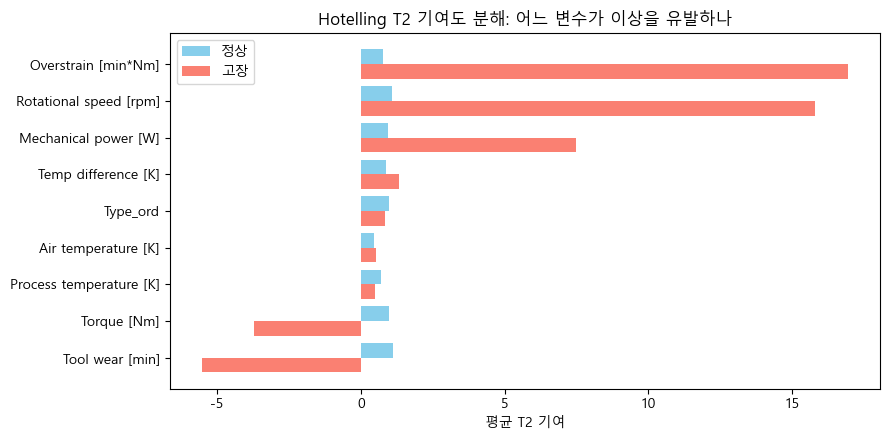

In [9]:
# T2 기여도 분해: 검증 데이터셋 고장 vs 정상에서 각 변수의 표준화 이탈 제곱 평균
prec = lw.precision_
# 1. 특정 센서의 값이 단순히 얼마나 튀었는지가 아니라, 다른 센서들과의 상관관계를 모두 고려했을 때 통계적으로 얼마나 이질적인 상태인지(가중치)를 계산
# 2. Row 기준 센서별 가중치 계산
contrib = (Zte @ prec) * Zte          # 변수별 T2 기여 (합이 근사 T2)
contrib = pd.DataFrame(contrib, columns=PHYS)
by_lab = contrib.assign(fail=y_te).groupby('fail').mean().T
by_lab.columns = ['정상', '고장']
by_lab = by_lab.sort_values('고장', ascending=False)
print('변수별 평균 T2 기여 (검증셋):')
print(by_lab.round(2).to_string())
print('\n고장에서 기여가 큰 변수 = 누적응력, 회전속도, 동력 (OSF/HDF/PWF와 일치).')
print('음수 기여는 오류가 아니라 상관 피처 간 교차항 탓. 부호보다 절대크기로 읽는다.')

fig, ax = plt.subplots(figsize=(9, 4.5))
yv = np.arange(len(by_lab))
ax.barh(yv - 0.2, by_lab['정상'], height=0.4, color='skyblue', label='정상')
ax.barh(yv + 0.2, by_lab['고장'], height=0.4, color='salmon', label='고장')
ax.set_yticks(yv)
ax.set_yticklabels(by_lab.index)
ax.invert_yaxis()
ax.set_xlabel('평균 T2 기여')
ax.set_title('Hotelling T2 기여도 분해: 어느 변수가 이상을 유발하나')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '04_t2_contribution.png', dpi=120)
plt.show()

## 7. 모델 비교

결과 정리. PR-AUC를 메인으로 확인.

                  PR_AUC  ROC_AUC  recall  precision     F1
model                                                      
Logistic-RAW       0.490    0.901   0.784      0.141  0.240
Logistic-PHYS      0.474    0.928   0.873      0.143  0.245
RF-RAW             0.761    0.967   0.343      0.897  0.496
RF-PHYS            0.889    0.969   0.784      0.988  0.874
HotellingT2-PHYS   0.322    0.870   0.824      0.110  0.194


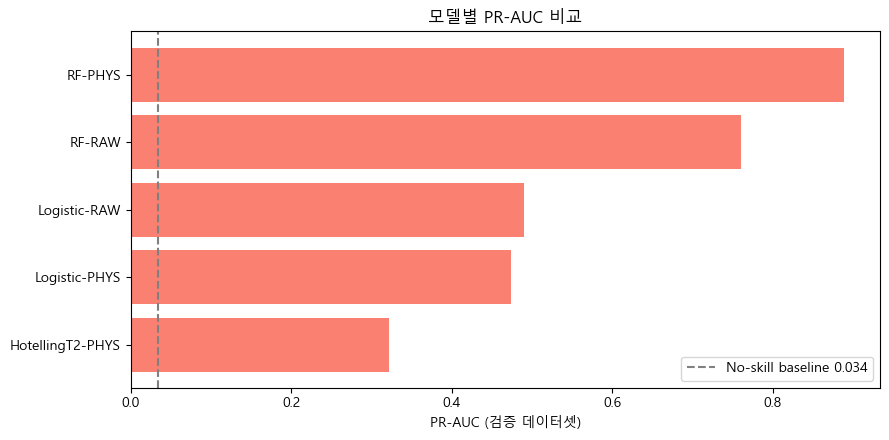


Raw 최고 PR-AUC 0.761 vs 물리 기반 피처 추가 최고 0.889 (차이 +0.129)


In [10]:
comp = pd.DataFrame(results).set_index('model')
print(comp.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
order = comp.sort_values('PR_AUC').index
ax.barh(order, comp.loc[order, 'PR_AUC'], color='salmon')
ax.axvline(y_te.mean(), color='gray', ls='--', label=f'No-skill baseline {y_te.mean():.3f}')
ax.set_xlabel('PR-AUC (검증 데이터셋)')
ax.set_title('모델별 PR-AUC 비교')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '04_model_comparison.png', dpi=120)
plt.show()

raw_best = comp.loc[['Logistic-RAW', 'RF-RAW'], 'PR_AUC'].max()
phys_best = comp.loc[['Logistic-PHYS', 'RF-PHYS'], 'PR_AUC'].max()
print(f'\nRaw 최고 PR-AUC {raw_best:.3f} vs 물리 기반 피처 추가 최고 {phys_best:.3f} '
      f'(차이 {phys_best-raw_best:+.3f})')

## 결론 (Phase 4)

- 학습/검증 데이터셋을 분리해 Phase 3의 데이터 전체 관점에서 결과의 한계를 해소하고, 처음 보는 데이터에서 평가.
- 물리 기반 피처 추가(RAW vs PHYS)의 예측 기여를 PR-AUC로 정량 비교.
- 로지스틱 오즈비로 각 물리량이 고장 오즈를 바꾸는 방향/크기를 해석(부트스트랩 CI).
- 다중공선성을 VIF로 진단하고, 선형모델은 정규화+다중공선성 처리한 데이터셋으로, 트리는 그대로, T제곱은
  Ledoit-Wolf 축소공분산으로 각각 대응.
- Hotelling T제곱: 정상만 학습하는 다변량 SPC로 불균형을 대처하고, 기여도 분해로
  어느 변수가 이상을 유발하는지까지 설명(제조 현장 관점).
- 한계: T제곱은 TWF(무작위 발생)처럼 센서로 안 드러나는 모드에는 한계가 있음을 확인. 전역 지표라
  개별 모드 구분은 기여도 분해에 의존.